# PHÂN TÍCH VÀ DỰ ĐOÁN XU HƯỚNG GIÁ XĂNG RON95 TẠI VIỆT NAM

**Bộ dữ liệu:** `vn_fuel_price_2018_present.csv`  
**Giai đoạn dữ liệu:** 08/05/2018 đến 31/05/2026  
**Biến phân tích chính:** `ron95_retail_price` - giá bán lẻ xăng RON95 tại Việt Nam, đơn vị VND/lít.

## 7 câu hỏi phân tích

1. Giá xăng RON95 cao nhất trong thời gian qua là ngày nào?
2. Tháng nào có giá xăng RON95 trung bình cao nhất?
3. Năm nào có giá xăng RON95 trung bình cao nhất và thấp nhất?
4. Giá dầu Brent thế giới có liên quan như thế nào đến giá xăng RON95 tại Việt Nam?
5. Giá xăng RON95 thay đổi mạnh nhất vào giai đoạn nào?
6. Dự đoán giá xăng RON95 trung bình trong 06 tháng cuối năm 2027?
7. Phân nhóm giá xăng RON95 thành thấp, trung bình và cao?

In [32]:
# ============================================================
# 0. IMPORT THU VIEN VA TAO THU MUC OUTPUT
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

OUTPUT_DIR = Path("output_ron95")
CHART_DIR = OUTPUT_DIR / "bieu_do"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

DATA_FILE = "vn_fuel_price_2018_present.csv"

print("Da tao thu muc output:", OUTPUT_DIR)
print("Da tao thu muc bieu do:", CHART_DIR)

Da tao thu muc output: output_ron95
Da tao thu muc bieu do: output_ron95\bieu_do


## 1. Đọc và tiền xử lý dữ liệu

In [33]:
# ============================================================
# 1. DOC DU LIEU
# ============================================================

if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
elif os.path.exists("/mnt/data/vn_fuel_price_2018_present.csv"):
    # Duong dan nay dung khi chay tren moi truong ChatGPT
    df = pd.read_csv("/mnt/data/vn_fuel_price_2018_present.csv")
else:
    raise FileNotFoundError(
        "Khong tim thay file vn_fuel_price_2018_present.csv. "
        "Hay dat file CSV cung thu muc voi notebook."
    )

print("Kich thuoc du lieu:", df.shape)
display(df.head())
print("Danh sach cot:")
print(df.columns.tolist())

Kich thuoc du lieu: (2946, 22)


,date,is_adjustment_day,usd_vnd,brent_usd_per_barrel,diesel_base_price,diesel_retail_price,diesel_bog_contribution,diesel_bog_spending,e5ron92_base_price,e5ron92_retail_price,e5ron92_bog_contribution,e5ron92_bog_spending,mazut_base_price,mazut_retail_price,mazut_bog_contribution,mazut_bog_spending,ron95_base_price,ron95_retail_price,ron95_bog_contribution,ron95_bog_spending,petrolimex_bog_ty_dong,pvoil_bog_ty_dong
0,08/05/2018,1,22805.0,74.160000,17307.0,17107.0,0.0,200.0,20398.0,19440.0,0.0,958.0,13759.0,13759.0,0.0,0.0,21362.0,21362.0,0.0,0.0,2620.0,194.058208
1,09/05/2018,0,22805.0,77.600000,17307.0,17107.0,0.0,200.0,20398.0,19440.0,0.0,958.0,13759.0,13759.0,0.0,0.0,21362.0,21362.0,0.0,0.0,2620.0,194.058208
2,10/05/2018,0,22805.0,77.590000,17307.0,17107.0,0.0,200.0,20398.0,19440.0,0.0,958.0,13759.0,13759.0,0.0,0.0,21362.0,21362.0,0.0,0.0,2620.0,194.058208
3,11/05/2018,0,22805.0,77.370000,17307.0,17107.0,0.0,200.0,20398.0,19440.0,0.0,958.0,13759.0,13759.0,0.0,0.0,21362.0,21362.0,0.0,0.0,2620.0,194.058208
4,12/05/2018,0,22805.0,77.636667,17307.0,17107.0,0.0,200.0,20398.0,19440.0,0.0,958.0,13759.0,13759.0,0.0,0.0,21362.0,21362.0,0.0,0.0,2620.0,194.058208


Danh sach cot:
['date', 'is_adjustment_day', 'usd_vnd', 'brent_usd_per_barrel', 'diesel_base_price', 'diesel_retail_price', 'diesel_bog_contribution', 'diesel_bog_spending', 'e5ron92_base_price', 'e5ron92_retail_price', 'e5ron92_bog_contribution', 'e5ron92_bog_spending', 'mazut_base_price', 'mazut_retail_price', 'mazut_bog_contribution', 'mazut_bog_spending', 'ron95_base_price', 'ron95_retail_price', 'ron95_bog_contribution', 'ron95_bog_spending', 'petrolimex_bog_ty_dong', 'pvoil_bog_ty_dong']


In [34]:
# ============================================================
# 2. TIEN XU LY DU LIEU
# ============================================================

# Chuyen cot ngay ve datetime. File dung dinh dang ngay/thang/nam.
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# Chuyen cac cot can dung ve dang so
cot_can_dung = [
    "ron95_retail_price",
    "brent_usd_per_barrel",
    "usd_vnd",
    "is_adjustment_day"
]

for col in cot_can_dung:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        print(f"Canh bao: Khong tim thay cot {col}")

# Chi giu cac dong co ngay va gia RON95
df = df.dropna(subset=["date", "ron95_retail_price"]).copy()

# Tao cot thoi gian ho tro phan tich
df["nam"] = df["date"].dt.year
df["thang"] = df["date"].dt.month
df["nam_thang"] = df["date"].dt.to_period("M").astype(str)
df["gia_ron95"] = df["ron95_retail_price"]

# Sap xep theo ngay
df = df.sort_values("date").reset_index(drop=True)

print("Khoang thoi gian du lieu:")
print(df["date"].min().date(), "den", df["date"].max().date())
print("So dong sau tien xu ly:", len(df))
display(df[["date", "gia_ron95", "brent_usd_per_barrel", "usd_vnd", "is_adjustment_day"]].head())

Khoang thoi gian du lieu:
2018-05-08 den 2026-05-31
So dong sau tien xu ly: 2946


,date,gia_ron95,brent_usd_per_barrel,usd_vnd,is_adjustment_day
0,2018-05-08,21362.0,74.160000,22805.0,1
1,2018-05-09,21362.0,77.600000,22805.0,0
2,2018-05-10,21362.0,77.590000,22805.0,0
3,2018-05-11,21362.0,77.370000,22805.0,0
4,2018-05-12,21362.0,77.636667,22805.0,0


## Câu 1. Giá xăng RON95 cao nhất trong thời gian qua là ngày nào?

CAU 1: GIA XANG RON95 CAO NHAT TRONG THOI GIAN QUA LA NGAY NAO?
Gia RON95 cao nhat: 32,873 VND/lit
Xuat hien tu ngay 2022-06-21 den ngay 2022-06-30
So ngay giu muc gia cao nhat: 10 ngay


,date,gia_ron95
1505,2022-06-21,32873.0
1506,2022-06-22,32873.0
1507,2022-06-23,32873.0
1508,2022-06-24,32873.0
1509,2022-06-25,32873.0
1510,2022-06-26,32873.0
1511,2022-06-27,32873.0
1512,2022-06-28,32873.0
1513,2022-06-29,32873.0
1514,2022-06-30,32873.0


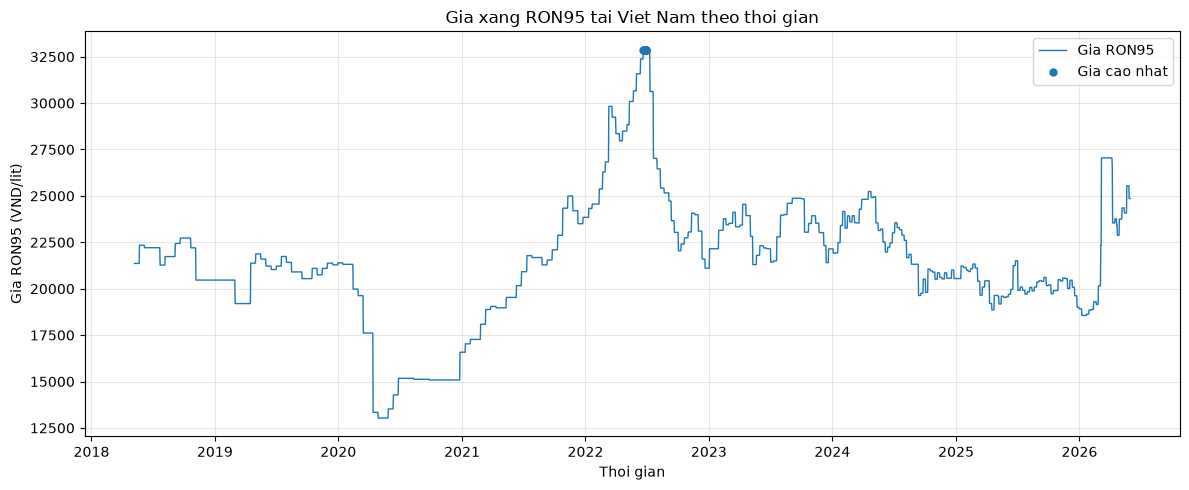


NHAN XET:
- Trong giai doan du lieu, gia xang RON95 cao nhat dat 32,873 VND/lit.
- Muc gia cao nhat nay xuat hien trong giai doan tu 2022-06-21 den 2022-06-30.


In [35]:
# ============================================================
# CAU 1: GIA XANG RON95 CAO NHAT LA NGAY NAO?
# ============================================================

gia_cao_nhat = df["gia_ron95"].max()
bang_gia_cao_nhat = df[df["gia_ron95"] == gia_cao_nhat][["date", "gia_ron95"]].copy()

ngay_dau = bang_gia_cao_nhat["date"].min()
ngay_cuoi = bang_gia_cao_nhat["date"].max()
so_ngay_giu_gia_cao_nhat = len(bang_gia_cao_nhat)

bang_gia_cao_nhat.to_csv(
    OUTPUT_DIR / "bang_01_gia_ron95_cao_nhat.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 1: GIA XANG RON95 CAO NHAT TRONG THOI GIAN QUA LA NGAY NAO?")
print("=" * 90)
print(f"Gia RON95 cao nhat: {gia_cao_nhat:,.0f} VND/lit")
print(f"Xuat hien tu ngay {ngay_dau.date()} den ngay {ngay_cuoi.date()}")
print(f"So ngay giu muc gia cao nhat: {so_ngay_giu_gia_cao_nhat} ngay")

display(bang_gia_cao_nhat)

# Ve bieu do gia RON95 theo thoi gian va danh dau gia cao nhat
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["gia_ron95"], linewidth=1, label="Gia RON95")
plt.scatter(bang_gia_cao_nhat["date"], bang_gia_cao_nhat["gia_ron95"], s=25, label="Gia cao nhat")
plt.title("Gia xang RON95 tai Viet Nam theo thoi gian")
plt.xlabel("Thoi gian")
plt.ylabel("Gia RON95 (VND/lit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_01_gia_ron95_cao_nhat.png", dpi=300)
plt.show()

print("\nNHAN XET:")
print(
    f"- Trong giai doan du lieu, gia xang RON95 cao nhat dat {gia_cao_nhat:,.0f} VND/lit."
)
print(
    f"- Muc gia cao nhat nay xuat hien trong giai doan tu {ngay_dau.date()} den {ngay_cuoi.date()}."
)

## Câu 2. Tháng nào có giá xăng RON95 trung bình cao nhất?

CAU 2: THANG NAO CO GIA XANG RON95 TRUNG BINH CAO NHAT?
Thang co gia RON95 trung binh cao nhat: Thang 3
Gia trung binh: 22,342 VND/lit
Thang co gia RON95 trung binh thap nhat: Thang 12
Gia trung binh: 20,701 VND/lit


,thang,gia_ron95_trung_binh,gia_ron95_cao_nhat,gia_ron95_thap_nhat,so_ngay
0,1,20888.911290,24560.0,16579.0,248
1,2,21405.553097,26287.0,17270.0,226
2,3,22342.020161,29824.0,17612.0,248
3,4,21923.700000,28492.0,13031.0,240
4,5,21714.003676,30657.0,13031.0,272
5,6,21850.125000,32873.0,13525.0,240
6,7,21907.713710,32763.0,15173.0,248
7,8,21405.701613,26458.0,15122.0,248
8,9,21175.633333,25162.0,15084.0,240
9,10,21030.766129,24871.0,15084.0,248


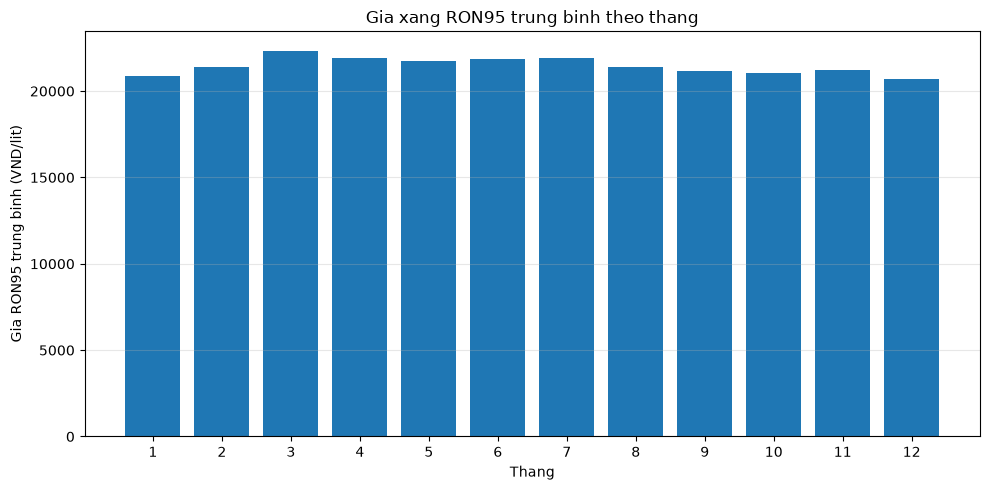


NHAN XET:
- Thang 3 co gia xang RON95 trung binh cao nhat, dat khoang 22,342 VND/lit.
- Thang 12 co gia xang RON95 trung binh thap nhat, dat khoang 20,701 VND/lit.


In [36]:
# ============================================================
# CAU 2: THANG NAO CO GIA RON95 TRUNG BINH CAO NHAT?
# ============================================================

bang_thang = df.groupby("thang").agg(
    gia_ron95_trung_binh=("gia_ron95", "mean"),
    gia_ron95_cao_nhat=("gia_ron95", "max"),
    gia_ron95_thap_nhat=("gia_ron95", "min"),
    so_ngay=("date", "count")
).reset_index()

bang_thang = bang_thang.sort_values("thang")

thang_cao_nhat = bang_thang.loc[bang_thang["gia_ron95_trung_binh"].idxmax()]
thang_thap_nhat = bang_thang.loc[bang_thang["gia_ron95_trung_binh"].idxmin()]

bang_thang.to_csv(
    OUTPUT_DIR / "bang_02_gia_ron95_trung_binh_theo_thang.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 2: THANG NAO CO GIA XANG RON95 TRUNG BINH CAO NHAT?")
print("=" * 90)
print(f"Thang co gia RON95 trung binh cao nhat: Thang {int(thang_cao_nhat['thang'])}")
print(f"Gia trung binh: {thang_cao_nhat['gia_ron95_trung_binh']:,.0f} VND/lit")
print(f"Thang co gia RON95 trung binh thap nhat: Thang {int(thang_thap_nhat['thang'])}")
print(f"Gia trung binh: {thang_thap_nhat['gia_ron95_trung_binh']:,.0f} VND/lit")

display(bang_thang)

plt.figure(figsize=(10, 5))
plt.bar(bang_thang["thang"], bang_thang["gia_ron95_trung_binh"])
plt.title("Gia xang RON95 trung binh theo thang")
plt.xlabel("Thang")
plt.ylabel("Gia RON95 trung binh (VND/lit)")
plt.xticks(range(1, 13))
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_02_gia_ron95_trung_binh_theo_thang.png", dpi=300)
plt.show()

print("\nNHAN XET:")
print(
    f"- Thang {int(thang_cao_nhat['thang'])} co gia xang RON95 trung binh cao nhat, "
    f"dat khoang {thang_cao_nhat['gia_ron95_trung_binh']:,.0f} VND/lit."
)
print(
    f"- Thang {int(thang_thap_nhat['thang'])} co gia xang RON95 trung binh thap nhat, "
    f"dat khoang {thang_thap_nhat['gia_ron95_trung_binh']:,.0f} VND/lit."
)

## Câu 3. Năm nào có giá xăng RON95 trung bình cao nhất và thấp nhất?

CAU 3: NAM NAO CO GIA XANG RON95 TRUNG BINH CAO NHAT VA THAP NHAT?
Nam co gia RON95 trung binh cao nhat: 2022
Gia trung binh: 26,361 VND/lit
Nam co gia RON95 trung binh thap nhat: 2020
Gia trung binh: 16,127 VND/lit


,nam,gia_ron95_trung_binh,gia_ron95_cao_nhat,gia_ron95_thap_nhat,so_ngay
0,2018,21716.193277,22730.0,20465.0,238
1,2019,20809.663014,21874.0,19199.0,365
2,2020,16126.827869,21390.0,13031.0,366
3,2021,20628.676712,24996.0,16579.0,365
4,2022,26360.583562,32873.0,21107.0,365
5,2023,23154.257534,24871.0,21107.0,365
6,2024,22375.445355,25237.0,19635.0,366
7,2025,20192.454795,21507.0,18856.0,365
8,2026,22575.397351,27047.0,18560.0,151


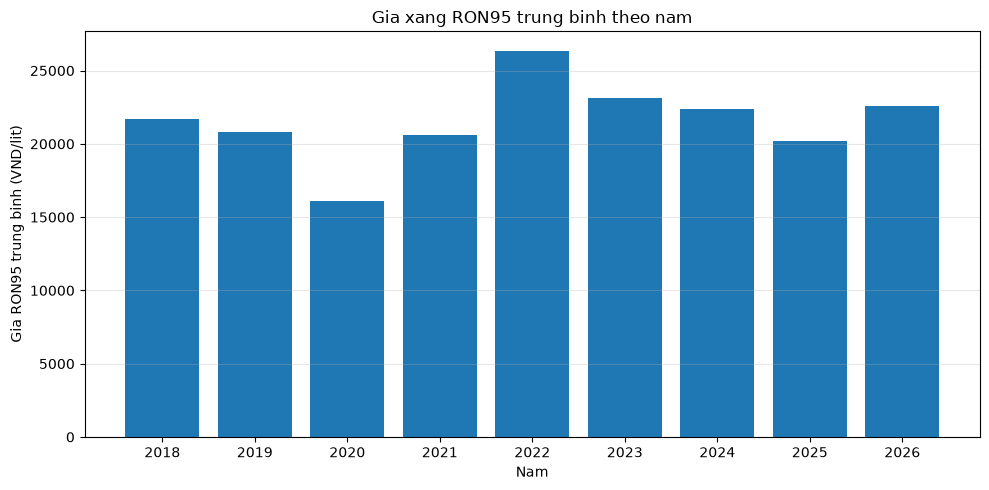


NHAN XET:
- Nam 2022 co gia xang RON95 trung binh cao nhat trong du lieu.
- Nam 2020 co gia xang RON95 trung binh thap nhat trong du lieu.


In [37]:
# ============================================================
# CAU 3: NAM NAO CO GIA RON95 TRUNG BINH CAO NHAT VA THAP NHAT?
# ============================================================

bang_nam = df.groupby("nam").agg(
    gia_ron95_trung_binh=("gia_ron95", "mean"),
    gia_ron95_cao_nhat=("gia_ron95", "max"),
    gia_ron95_thap_nhat=("gia_ron95", "min"),
    so_ngay=("date", "count")
).reset_index()

nam_cao_nhat = bang_nam.loc[bang_nam["gia_ron95_trung_binh"].idxmax()]
nam_thap_nhat = bang_nam.loc[bang_nam["gia_ron95_trung_binh"].idxmin()]

bang_nam.to_csv(
    OUTPUT_DIR / "bang_03_gia_ron95_trung_binh_theo_nam.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 3: NAM NAO CO GIA XANG RON95 TRUNG BINH CAO NHAT VA THAP NHAT?")
print("=" * 90)
print(f"Nam co gia RON95 trung binh cao nhat: {int(nam_cao_nhat['nam'])}")
print(f"Gia trung binh: {nam_cao_nhat['gia_ron95_trung_binh']:,.0f} VND/lit")
print(f"Nam co gia RON95 trung binh thap nhat: {int(nam_thap_nhat['nam'])}")
print(f"Gia trung binh: {nam_thap_nhat['gia_ron95_trung_binh']:,.0f} VND/lit")

display(bang_nam)

plt.figure(figsize=(10, 5))
plt.bar(bang_nam["nam"].astype(str), bang_nam["gia_ron95_trung_binh"])
plt.title("Gia xang RON95 trung binh theo nam")
plt.xlabel("Nam")
plt.ylabel("Gia RON95 trung binh (VND/lit)")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_03_gia_ron95_trung_binh_theo_nam.png", dpi=300)
plt.show()

print("\nNHAN XET:")
print(
    f"- Nam {int(nam_cao_nhat['nam'])} co gia xang RON95 trung binh cao nhat trong du lieu."
)
print(
    f"- Nam {int(nam_thap_nhat['nam'])} co gia xang RON95 trung binh thap nhat trong du lieu."
)

## Câu 4. Giá dầu Brent thế giới có liên quan như thế nào đến giá xăng RON95 tại Việt Nam?

CAU 4: GIA DAU BRENT THE GIOI CO LIEN QUAN NHU THE NAO DEN GIA XANG RON95 TAI VIET NAM?
He so tuong quan Pearson giua Brent va RON95: 0.897


,chi_tieu,gia_tri
0,He so tuong quan Pearson,0.897474


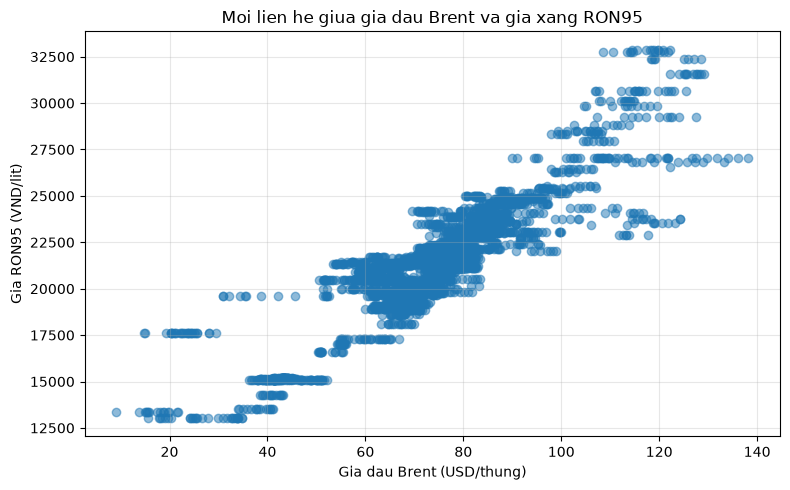

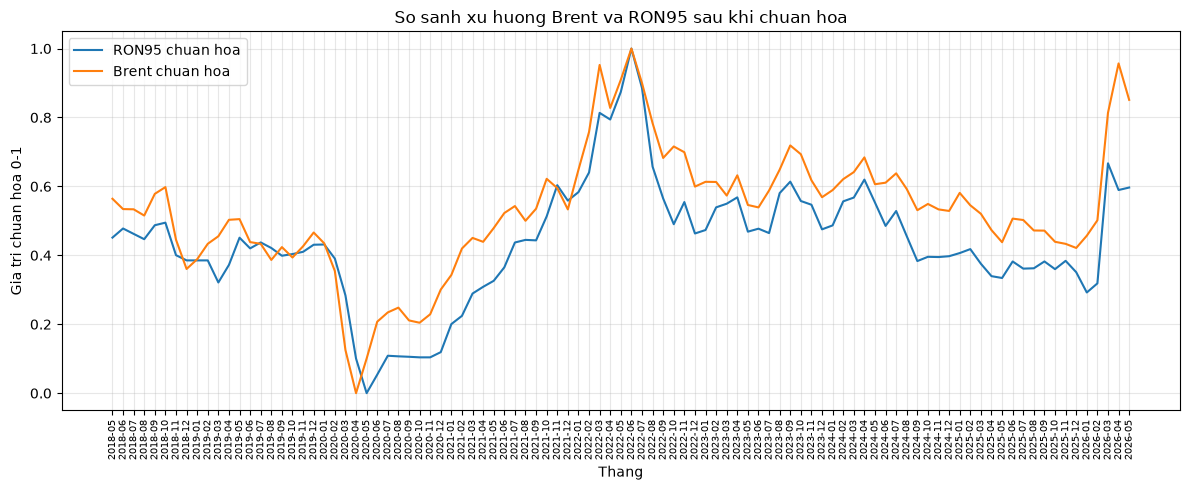


NHAN XET:
- He so tuong quan la 0.897, cho thay Brent va RON95 co moi lien he cung chieu kha manh.
- Gia dau Brent co the la mot yeu to tham khao quan trong, nhung gia RON95 tai Viet Nam con phu thuoc vao thue, phi, ty gia va ky dieu chinh gia.


In [38]:
# ============================================================
# CAU 4: MOI LIEN HE GIUA BRENT VA GIA XANG RON95
# ============================================================

bang_brent = df.dropna(subset=["brent_usd_per_barrel", "gia_ron95"]).copy()

he_so_tuong_quan = bang_brent["brent_usd_per_barrel"].corr(bang_brent["gia_ron95"])

bang_tuong_quan = pd.DataFrame({
    "chi_tieu": ["He so tuong quan Pearson"],
    "gia_tri": [he_so_tuong_quan]
})

bang_tuong_quan.to_csv(
    OUTPUT_DIR / "bang_04_tuong_quan_brent_ron95.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 4: GIA DAU BRENT THE GIOI CO LIEN QUAN NHU THE NAO DEN GIA XANG RON95 TAI VIET NAM?")
print("=" * 90)
print(f"He so tuong quan Pearson giua Brent va RON95: {he_so_tuong_quan:.3f}")

display(bang_tuong_quan)

plt.figure(figsize=(8, 5))
plt.scatter(
    bang_brent["brent_usd_per_barrel"],
    bang_brent["gia_ron95"],
    alpha=0.5
)
plt.title("Moi lien he giua gia dau Brent va gia xang RON95")
plt.xlabel("Gia dau Brent (USD/thung)")
plt.ylabel("Gia RON95 (VND/lit)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_04_tuong_quan_brent_ron95.png", dpi=300)
plt.show()

# Ve 2 duong sau khi chuan hoa de de so sanh xu huong
bang_monthly_relation = df.groupby("nam_thang").agg(
    gia_ron95=("gia_ron95", "mean"),
    brent=("brent_usd_per_barrel", "mean")
).reset_index().dropna()

# Chuan hoa ve thang 0-1 de so sanh tren cung bieu do
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

bang_monthly_relation["ron95_chuan_hoa"] = minmax(bang_monthly_relation["gia_ron95"])
bang_monthly_relation["brent_chuan_hoa"] = minmax(bang_monthly_relation["brent"])

plt.figure(figsize=(12, 5))
plt.plot(bang_monthly_relation["nam_thang"], bang_monthly_relation["ron95_chuan_hoa"], label="RON95 chuan hoa")
plt.plot(bang_monthly_relation["nam_thang"], bang_monthly_relation["brent_chuan_hoa"], label="Brent chuan hoa")
plt.title("So sanh xu huong Brent va RON95 sau khi chuan hoa")
plt.xlabel("Thang")
plt.ylabel("Gia tri chuan hoa 0-1")
plt.xticks(rotation=90, fontsize=7)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_04_so_sanh_xu_huong_brent_ron95.png", dpi=300)
plt.show()

print("\nNHAN XET:")
if he_so_tuong_quan >= 0.7:
    muc_do = "co moi lien he cung chieu kha manh"
elif he_so_tuong_quan >= 0.4:
    muc_do = "co moi lien he cung chieu trung binh"
elif he_so_tuong_quan >= 0.1:
    muc_do = "co moi lien he cung chieu yeu"
elif he_so_tuong_quan > -0.1:
    muc_do = "gan nhu khong co moi lien he tuyen tinh ro rang"
else:
    muc_do = "co moi lien he nguoc chieu"

print(f"- He so tuong quan la {he_so_tuong_quan:.3f}, cho thay Brent va RON95 {muc_do}.")
print("- Gia dau Brent co the la mot yeu to tham khao quan trong, nhung gia RON95 tai Viet Nam con phu thuoc vao thue, phi, ty gia va ky dieu chinh gia.")

## Câu 5. Giá xăng RON95 thay đổi mạnh nhất vào giai đoạn nào?

CAU 5: GIA XANG RON95 THAY DOI MANH NHAT VAO GIAI DOAN NAO?
Bien dong manh nhat:
- Ngay: 2026-03-07
- Gia RON95: 27,047 VND/lit
- Muc thay doi: 4,707 VND/lit
- Phan tram thay doi: 21.07%

Tang manh nhat:
- Ngay: 2026-03-07
- Tang: 4,707 VND/lit

Giam manh nhat:
- Ngay: 2020-04-13
- Giam: -4,273 VND/lit


,date,gia_ron95,is_adjustment_day,thay_doi_gia,thay_doi_tuyet_doi,phan_tram_thay_doi
15,2018-05-23,22342.0,1,980.0,980.0,4.587585
30,2018-06-07,22209.0,1,-133.0,133.0,-0.595291
76,2018-07-23,21272.0,1,-937.0,937.0,-4.219010
91,2018-08-07,21731.0,1,459.0,459.0,2.157766
121,2018-09-06,22437.0,1,706.0,706.0,3.248815
...,...,...,...,...,...,...
2913,2026-04-29,23751.0,1,871.0,871.0,3.806818
2921,2026-05-07,24354.0,1,603.0,603.0,2.538840
2928,2026-05-14,24078.0,1,-276.0,276.0,-1.133284
2935,2026-05-21,25549.0,1,1471.0,1471.0,6.109311


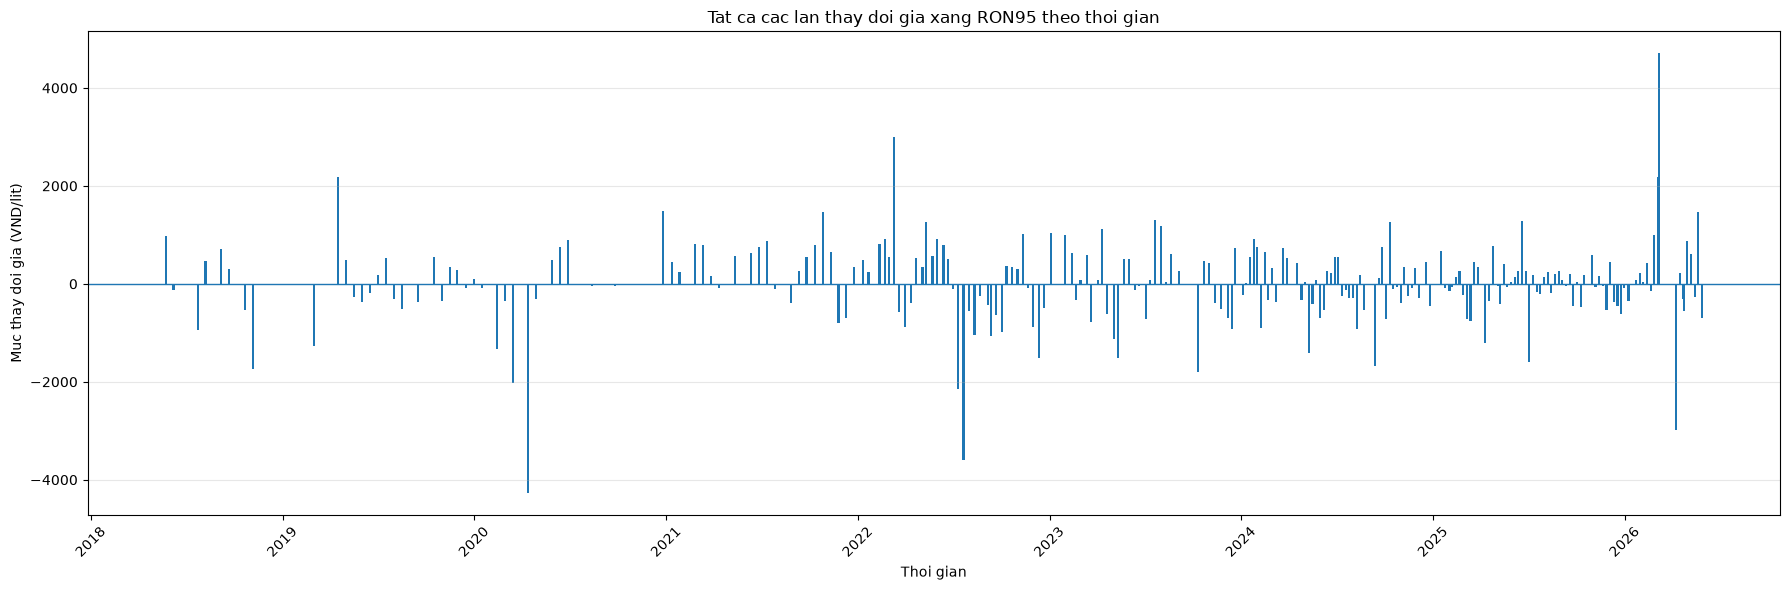


NHAN XET:
- Gia RON95 thay doi manh nhat vao ngay 2026-03-07, voi muc thay doi 4,707 VND/lit.
- Ngay tang manh nhat la 2026-03-07, tang 4,707 VND/lit.
- Ngay giam manh nhat la 2020-04-13, giam -4,273 VND/lit.
- Bieu do cho thay gia xang RON95 co nhieu lan dieu chinh tang va giam trong giai doan du lieu.

Da luu bang ket qua:
- output_ron95/bang_05_bien_dong_gia_ron95.csv

Da luu bieu do:
- output_ron95/bieu_do/bieu_do_05_tat_ca_bien_dong_gia_ron95.png


In [43]:
# ============================================================
# CAU 5: GIA XANG RON95 THAY DOI MANH NHAT VAO GIAI DOAN NAO?
# ============================================================

bang_bien_dong = df[["date", "gia_ron95", "is_adjustment_day"]].copy()

# Tinh muc thay doi gia so voi ngay truoc do
bang_bien_dong["thay_doi_gia"] = bang_bien_dong["gia_ron95"].diff()

# Lay gia tri tuyet doi de tim ngay bien dong manh nhat
bang_bien_dong["thay_doi_tuyet_doi"] = bang_bien_dong["thay_doi_gia"].abs()

# Tinh phan tram thay doi
bang_bien_dong["phan_tram_thay_doi"] = bang_bien_dong["gia_ron95"].pct_change() * 100

# Chi lay cac ngay co thay doi gia khac 0
bang_ngay_thay_doi = bang_bien_dong[
    bang_bien_dong["thay_doi_tuyet_doi"] > 0
].copy()

# Tim ngay bien dong manh nhat, tang manh nhat va giam manh nhat
bien_dong_manh_nhat = bang_ngay_thay_doi.loc[
    bang_ngay_thay_doi["thay_doi_tuyet_doi"].idxmax()
]

tang_manh_nhat = bang_ngay_thay_doi.loc[
    bang_ngay_thay_doi["thay_doi_gia"].idxmax()
]

giam_manh_nhat = bang_ngay_thay_doi.loc[
    bang_ngay_thay_doi["thay_doi_gia"].idxmin()
]

# Luu bang ket qua
bang_ngay_thay_doi.to_csv(
    OUTPUT_DIR / "bang_05_bien_dong_gia_ron95.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 5: GIA XANG RON95 THAY DOI MANH NHAT VAO GIAI DOAN NAO?")
print("=" * 90)

print("Bien dong manh nhat:")
print(f"- Ngay: {bien_dong_manh_nhat['date'].date()}")
print(f"- Gia RON95: {bien_dong_manh_nhat['gia_ron95']:,.0f} VND/lit")
print(f"- Muc thay doi: {bien_dong_manh_nhat['thay_doi_gia']:,.0f} VND/lit")
print(f"- Phan tram thay doi: {bien_dong_manh_nhat['phan_tram_thay_doi']:.2f}%")

print("\nTang manh nhat:")
print(f"- Ngay: {tang_manh_nhat['date'].date()}")
print(f"- Tang: {tang_manh_nhat['thay_doi_gia']:,.0f} VND/lit")

print("\nGiam manh nhat:")
print(f"- Ngay: {giam_manh_nhat['date'].date()}")
print(f"- Giam: {giam_manh_nhat['thay_doi_gia']:,.0f} VND/lit")

# Hien thi bang cac ngay co bien dong gia
display(bang_ngay_thay_doi)

# ============================================================
# BIEU DO: HIEN THI TAT CA CAC NGAY CO BIEN DONG GIA
# ============================================================

plt.figure(figsize=(18, 6))

plt.bar(
    bang_ngay_thay_doi["date"],
    bang_ngay_thay_doi["thay_doi_gia"],
    width=4
)

plt.axhline(0, linewidth=1)

plt.title("Tat ca cac lan thay doi gia xang RON95 theo thoi gian")
plt.xlabel("Thoi gian")
plt.ylabel("Muc thay doi gia (VND/lit)")

plt.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "bieu_do_05_tat_ca_bien_dong_gia_ron95.png",
    dpi=300
)

plt.show()

print("\nNHAN XET:")

print(
    f"- Gia RON95 thay doi manh nhat vao ngay {bien_dong_manh_nhat['date'].date()}, "
    f"voi muc thay doi {bien_dong_manh_nhat['thay_doi_gia']:,.0f} VND/lit."
)

print(
    f"- Ngay tang manh nhat la {tang_manh_nhat['date'].date()}, "
    f"tang {tang_manh_nhat['thay_doi_gia']:,.0f} VND/lit."
)

print(
    f"- Ngay giam manh nhat la {giam_manh_nhat['date'].date()}, "
    f"giam {giam_manh_nhat['thay_doi_gia']:,.0f} VND/lit."
)

print(
    "- Bieu do cho thay gia xang RON95 co nhieu lan dieu chinh tang va giam "
    "trong giai doan du lieu."
)

print("\nDa luu bang ket qua:")
print("- output_ron95/bang_05_bien_dong_gia_ron95.csv")

print("\nDa luu bieu do:")
print("- output_ron95/bieu_do/bieu_do_05_tat_ca_bien_dong_gia_ron95.png")

## Câu 6. Dự đoán giá xăng RON95 trung bình trong 06 tháng cuối năm 2027

Phương pháp sử dụng trong notebook này là mô hình hồi quy tuyến tính theo thời gian kết hợp đặc điểm mùa vụ theo tháng. Cách làm này đơn giản, dễ giải thích trong báo cáo và không cần cài thêm thư viện ngoài.

CAU 6: DU DOAN GIA XANG RON95 TRUNG BINH TRONG 06 THANG CUOI NAM 2027
Gia RON95 trung binh lich su: 21,466 VND/lit


,thang,nam,thang_so,gia_ron95_du_doan,gia_trung_binh_lich_su,danh_gia
0,2027-07,2027,7,23295.0,21466.0,Cao hon trung binh lich su
1,2027-08,2027,8,22793.0,21466.0,Cao hon trung binh lich su
2,2027-09,2027,9,22562.0,21466.0,Cao hon trung binh lich su
3,2027-10,2027,10,22418.0,21466.0,Cao hon trung binh lich su
4,2027-11,2027,11,22608.0,21466.0,Cao hon trung binh lich su
5,2027-12,2027,12,22088.0,21466.0,Cao hon trung binh lich su


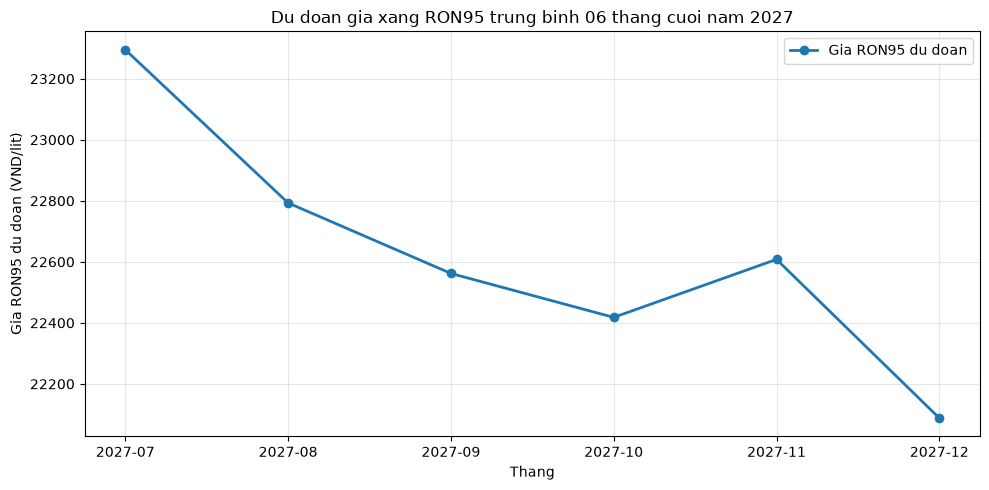


NHAN XET:
- Gia RON95 du doan trong 06 thang cuoi nam 2027 co su thay doi theo tung thang.
- Ket qua du doan chi mang tinh tham khao vi gia xang con phu thuoc vao gia dau the gioi, ty gia, thue phi va chinh sach dieu hanh gia.


In [44]:
# ============================================================
# CAU 6: DU DOAN GIA RON95 TRUNG BINH 06 THANG CUOI NAM 2027
# ============================================================

# Tinh gia trung binh theo thang
bang_thang_nam = df.groupby("nam_thang").agg(
    ngay_dai_dien=("date", "min"),
    nam=("nam", "first"),
    thang=("thang", "first"),
    gia_ron95_trung_binh=("gia_ron95", "mean"),
    brent_trung_binh=("brent_usd_per_barrel", "mean"),
    usd_vnd_trung_binh=("usd_vnd", "mean")
).reset_index()

bang_thang_nam = bang_thang_nam.sort_values("ngay_dai_dien").reset_index(drop=True)
bang_thang_nam["t"] = np.arange(len(bang_thang_nam))

# Mo hinh xu huong theo thoi gian
X = bang_thang_nam[["t"]]
y = bang_thang_nam["gia_ron95_trung_binh"]

model = LinearRegression()
model.fit(X, y)

bang_thang_nam["du_doan_train"] = model.predict(X)
bang_thang_nam["sai_so_mua_vu"] = bang_thang_nam["gia_ron95_trung_binh"] - bang_thang_nam["du_doan_train"]

# Sai so mua vu trung binh theo thang
mua_vu_theo_thang = bang_thang_nam.groupby("thang")["sai_so_mua_vu"].mean().to_dict()

# Du doan cho 6 thang cuoi nam 2027
thang_du_doan = pd.date_range("2027-07-01", "2027-12-01", freq="MS")

last_t = bang_thang_nam["t"].max()
future_rows = []

for i, ngay in enumerate(thang_du_doan, start=1):
    t_future = last_t + i
    xu_huong = model.predict(pd.DataFrame({"t": [t_future]}))[0]
    thanh_phan_mua_vu = mua_vu_theo_thang.get(ngay.month, 0)
    gia_du_doan = xu_huong + thanh_phan_mua_vu
    future_rows.append({
        "thang": ngay.strftime("%Y-%m"),
        "nam": ngay.year,
        "thang_so": ngay.month,
        "gia_ron95_du_doan": round(gia_du_doan, 0)
    })

bang_du_doan = pd.DataFrame(future_rows)

# Danh gia cao/thap so voi gia trung binh lich su
gia_tb_lich_su = bang_thang_nam["gia_ron95_trung_binh"].mean()
bang_du_doan["gia_trung_binh_lich_su"] = round(gia_tb_lich_su, 0)
bang_du_doan["danh_gia"] = np.where(
    bang_du_doan["gia_ron95_du_doan"] >= gia_tb_lich_su,
    "Cao hon trung binh lich su",
    "Thap hon trung binh lich su"
)

bang_du_doan.to_csv(
    OUTPUT_DIR / "bang_06_du_doan_gia_ron95_06_thang_cuoi_2027.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 6: DU DOAN GIA XANG RON95 TRUNG BINH TRONG 06 THANG CUOI NAM 2027")
print("=" * 90)
print(f"Gia RON95 trung binh lich su: {gia_tb_lich_su:,.0f} VND/lit")
display(bang_du_doan)

# Ve bieu do chi hien thi ket qua du doan
plt.figure(figsize=(10, 5))

plt.plot(
    bang_du_doan["thang"],
    bang_du_doan["gia_ron95_du_doan"],
    marker="o",
    linewidth=2,
    label="Gia RON95 du doan"
)

plt.title("Du doan gia xang RON95 trung binh 06 thang cuoi nam 2027")
plt.xlabel("Thang")
plt.ylabel("Gia RON95 du doan (VND/lit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    CHART_DIR / "bieu_do_06_chi_du_doan_gia_ron95_06_thang_cuoi_2027.png",
    dpi=300
)

plt.show()

print("\nNHAN XET:")
print("- Gia RON95 du doan trong 06 thang cuoi nam 2027 co su thay doi theo tung thang.")
print("- Ket qua du doan chi mang tinh tham khao vi gia xang con phu thuoc vao gia dau the gioi, ty gia, thue phi va chinh sach dieu hanh gia.")

## Câu 7. Phân nhóm giá xăng RON95 thành thấp, trung bình và cao

CAU 7: PHAN NHOM GIA XANG RON95 THANH THAP, TRUNG BINH VA CAO
Nguong nhom gia thap: <= 20,465 VND/lit
Nguong nhom gia trung binh: > 20,465 va <= 22,342 VND/lit
Nguong nhom gia cao: > 22,342 VND/lit


,nhom_gia,so_ngay,gia_trung_binh,gia_thap_nhat,gia_cao_nhat,ty_le_%
1,Gia thap,1003,18185.993021,13031.0,20465.0,34.046164
2,Gia trung binh,963,21410.741433,20488.0,22342.0,32.688391
0,Gia cao,980,24875.747959,22407.0,32873.0,33.265445


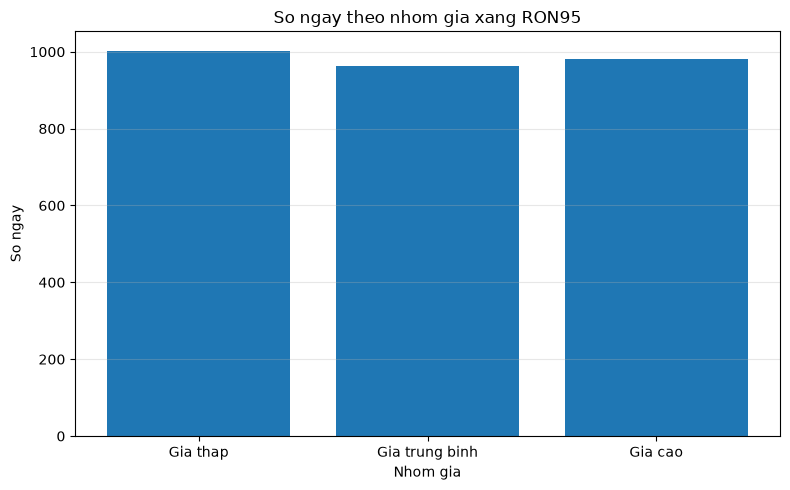

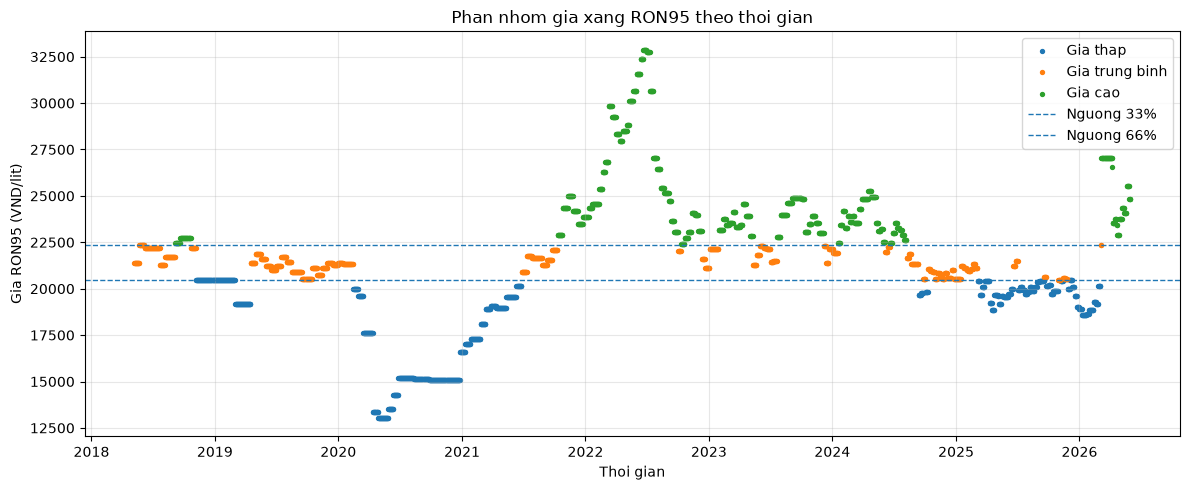


NHAN XET:
- Gia RON95 duoc chia thanh 03 nhom dua tren phan vi cua du lieu: thap, trung binh va cao.
- Cach phan nhom nay giup nguoi doc de nhan biet cac giai doan gia xang o muc thap, trung binh hoac cao.


In [41]:
# ============================================================
# CAU 7: PHAN NHOM GIA XANG RON95 THANH THAP, TRUNG BINH, CAO
# ============================================================

# Phan nhom theo phan vi 33% va 66%
nguong_33 = df["gia_ron95"].quantile(1/3)
nguong_66 = df["gia_ron95"].quantile(2/3)

def phan_nhom_gia(gia):
    if gia <= nguong_33:
        return "Gia thap"
    elif gia <= nguong_66:
        return "Gia trung binh"
    else:
        return "Gia cao"

bang_phan_nhom = df[["date", "gia_ron95"]].copy()
bang_phan_nhom["nhom_gia"] = bang_phan_nhom["gia_ron95"].apply(phan_nhom_gia)

thong_ke_nhom = bang_phan_nhom.groupby("nhom_gia").agg(
    so_ngay=("date", "count"),
    gia_trung_binh=("gia_ron95", "mean"),
    gia_thap_nhat=("gia_ron95", "min"),
    gia_cao_nhat=("gia_ron95", "max")
).reset_index()

thu_tu = ["Gia thap", "Gia trung binh", "Gia cao"]
thong_ke_nhom["thu_tu"] = thong_ke_nhom["nhom_gia"].map({v: i for i, v in enumerate(thu_tu)})
thong_ke_nhom = thong_ke_nhom.sort_values("thu_tu").drop(columns="thu_tu")
thong_ke_nhom["ty_le_%"] = thong_ke_nhom["so_ngay"] / len(bang_phan_nhom) * 100

bang_phan_nhom.to_csv(
    OUTPUT_DIR / "bang_07_phan_nhom_gia_ron95_theo_ngay.csv",
    index=False,
    encoding="utf-8-sig"
)

thong_ke_nhom.to_csv(
    OUTPUT_DIR / "bang_07_thong_ke_nhom_gia_ron95.csv",
    index=False,
    encoding="utf-8-sig"
)

print("=" * 90)
print("CAU 7: PHAN NHOM GIA XANG RON95 THANH THAP, TRUNG BINH VA CAO")
print("=" * 90)
print(f"Nguong nhom gia thap: <= {nguong_33:,.0f} VND/lit")
print(f"Nguong nhom gia trung binh: > {nguong_33:,.0f} va <= {nguong_66:,.0f} VND/lit")
print(f"Nguong nhom gia cao: > {nguong_66:,.0f} VND/lit")

display(thong_ke_nhom)

plt.figure(figsize=(8, 5))
plt.bar(thong_ke_nhom["nhom_gia"], thong_ke_nhom["so_ngay"])
plt.title("So ngay theo nhom gia xang RON95")
plt.xlabel("Nhom gia")
plt.ylabel("So ngay")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_07_so_ngay_theo_nhom_gia_ron95.png", dpi=300)
plt.show()

plt.figure(figsize=(12, 5))

for nhom in thu_tu:
    data_nhom = bang_phan_nhom[bang_phan_nhom["nhom_gia"] == nhom]
    plt.scatter(data_nhom["date"], data_nhom["gia_ron95"], s=8, label=nhom)

plt.axhline(nguong_33, linestyle="--", linewidth=1, label="Nguong 33%")
plt.axhline(nguong_66, linestyle="--", linewidth=1, label="Nguong 66%")
plt.title("Phan nhom gia xang RON95 theo thoi gian")
plt.xlabel("Thoi gian")
plt.ylabel("Gia RON95 (VND/lit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "bieu_do_07_phan_nhom_gia_ron95_theo_thoi_gian.png", dpi=300)
plt.show()

print("\nNHAN XET:")
print("- Gia RON95 duoc chia thanh 03 nhom dua tren phan vi cua du lieu: thap, trung binh va cao.")
print("- Cach phan nhom nay giup nguoi doc de nhan biet cac giai doan gia xang o muc thap, trung binh hoac cao.")

# Tổng kết

Notebook đã thực hiện đầy đủ 7 câu hỏi của đề tài:

1. Xác định ngày có giá RON95 cao nhất.
2. Phân tích giá RON95 trung bình theo tháng.
3. Phân tích giá RON95 trung bình theo năm.
4. Phân tích mối liên hệ giữa giá dầu Brent thế giới và giá RON95 tại Việt Nam.
5. Xác định giai đoạn giá RON95 biến động mạnh nhất.
6. Dự đoán giá RON95 trung bình trong 06 tháng cuối năm 2027.
7. Phân nhóm giá RON95 thành thấp, trung bình và cao.

Các bảng kết quả được lưu trong thư mục `output_ron95`.  
Các biểu đồ được lưu trong thư mục `output_ron95/bieu_do`.